# Does a difference-of-Gaussians edge filter sharpen DAPI's stitching registration?

`test_dapi_inversion.ipynb` confirmed (both `epi` and `disk`) that inverting
DAPI (`2**16 - I`) does not change its registration behaviour at all --
expected, since that transform is affine and the registration primitives
used here (`phase_cross_correlation`, Pearson-correlation-based
`overlap_correlation`) are affine-invariant. Its Discussion section framed
*why* beads outperform DAPI in a follow-up chat exchange: shift-estimation
precision from a correlation-based estimator is governed by the
Cramer-Rao bound `Var(shift) >= sigma_noise^2 / integral((dI/dx)^2) dx` --
i.e. by an image's high-spatial-frequency (gradient) content, not its
intensity range. Beads concentrate energy at high spatial frequency
(near-point sources); DAPI's broad nuclear blobs are dominated by low
frequency and contribute little to that integral.

**Hypothesis under test here**: an edge-enhancing filter that raises DAPI's
high-frequency content *should* raise `integral((dI/dx)^2) dx` and sharpen
its correlation response, unlike inversion. A difference-of-Gaussians
(DoG) filter -- `blur(sigma_low) - blur(sigma_high)` -- is used rather than
a plain gradient operator (Sobel/Scharr/Laplacian) because differentiation
alone amplifies high-frequency pixel noise right along with real edges; DoG
is a genuine bandpass (suppresses both the very-low-frequency smooth
nuclear body AND very-high-frequency noise, keeping the mid-band where
edges live) and stays continuous-valued, unlike a binarizing detector
(Canny) that would throw away the sub-pixel intensity gradation a
correlation-based estimator needs.

**Filter parameters**: `low_sigma=1.0px`, `high_sigma=8.0px`
(`skimage.filters.difference_of_gaussians`). An attempt to set `high_sigma`
from a measured nucleus size (Otsu threshold + connected components on a
real `disk` DAPI frame) was tried first but was not usable: `disk`'s
DAPI signal is dim/noisy enough that Otsu fragmented the image into 10439
components, only 380 surviving even a modest area filter, with a median
equivalent diameter (~12.5px) implausibly small for a real nucleus -- not
a reliable size estimate on this dataset. Falling back to these standard,
untuned defaults instead; Section 4's sanity-check picture shows the
actual filtered output on a real frame so the choice can be visually
judged rather than only assumed.

**Disk dataset only** (per this investigation's scope) -- `disk` is where
beads are known weak (`test_bead_intensity_and_count_epi_vs_disk.ipynb`),
so it is also the dataset where a real DAPI-side improvement would matter
most in practice.

**Same three tests as `test_dapi_inversion.ipynb`**, real `cells`-round
frames only (beads = frame 0, DAPI = 405nm z-index 3):

1. **Self-shift** (Sections 5-6): one real image per channel vs. a
   synthetic shift of ITSELF -- correlation is exactly 1.0 at shift=0 by
   construction; its decay away from 0 measures that channel's own
   spatial-content sharpness in isolation.
2. **Cross-tile** (Sections 7-8): real anchor/neighbour tile pairs, small
   synthetic shifts swept around their real measured alignment -- both a
   single real edge (no averaging) and the mean +/- std over
   `N_EDGES_FOR_SHIFT_CURVE` edges.
3. **Practical** (Sections 9-10): real whole-grid registration sample
   (`register_neighbor_pair`, replayed in small batches per
   `test_dapi_inversion.ipynb`'s own memory-safety fix), compared via
   `overlap_correlation` evaluated at each edge's achieved alignment
   (`achieved_correlation`) -- not `NeighborCorrespondence.error`, which
   `test_dapi_inversion.ipynb` found saturates near 1.0 for real 16-bit
   input under skimage's default `phase_cross_correlation` normalization.

Follows `NOTEBOOK_GUIDELINES.md`: calculation cells cached under
`analysis/cache/test_dapi_edge_filter/`, skip recomputation when a valid
cache exists, `ProgressReporter` progress, explicit plot font sizes, every
displayed figure also saved to `analysis/figures/`.

## 1 — Setup

In [1]:
import os
import sys
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift
from scipy.spatial import KDTree
from skimage.filters import difference_of_gaussians

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/tests/fov_stitching/07_test_dapi_inversion.ipynb.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import (
    find_frame_table_for_hal_config, get_camera_pixel_size_um, get_camera_frame_size,
    get_all_color_frame_indices,
)
from MERci.acquisition.positions       import find_grid_neighbor
from MERci.acquisition.camera_rotation import (
    apply_microscope_orientation, crop_overlap, register_neighbor_pair, overlap_correlation,
)
from MERci.acquisition.alignment  import remove_hot_pixels, phase_drift
from MERci.acquisition.merlin_config import load_microscope_orientation
from MERci.progress_display       import ProgressReporter
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "test_dapi_edge_filter"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# disk only -- known-weak-beads half of the same sample test_dapi_inversion.ipynb
# already used, the strongest real test of whether a DAPI-side fix could help.
DATASETS = [
    ("disk", "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk"),
]
IMAGE_SUFFIX = ".zarr"

BEAD_FRAME_INDEX = 0     # HAL's own bead/fiducial frame convention (cells round)
DAPI_COLOR_NM    = 405.0
DAPI_Z_INDEX     = 3     # same z-index test_dapi_inversion.ipynb / test_stitching.ipynb use

CHANNELS = ("beads", "dapi_raw", "dapi_edge")
CHANNEL_COLORS = {"beads": "tab:blue", "dapi_raw": "tab:orange", "dapi_edge": "tab:red"}

# Difference-of-Gaussians bandpass -- see this notebook's own intro markdown
# for why these values (a nucleus-size-based estimate was tried and was not
# reliable on this dataset); Section 4 shows the real filtered output.
DOG_LOW_SIGMA  = 1.0   # px -- suppress above-Nyquist pixel noise
DOG_HIGH_SIGMA = 8.0   # px -- suppress the smooth, low-frequency nuclear body

TOLERANCE_FRACTION = 0.25   # same default as find_grid_neighbor
UPSAMPLE_FACTOR     = 10    # sub-pixel registration precision (1/UPSAMPLE_FACTOR px)
SEED = 0

# Sections 5-8: synthetic sub-pixel shift sweep, shared by both the
# self-shift and cross-tile mechanistic tests.
SHIFT_RANGE_PX = np.arange(-3.0, 3.01, 0.25)
N_EDGES_FOR_SHIFT_CURVE = 8   # cross-tile test only

# Section 9 (practical): same real-anchor sample size test_dapi_inversion.ipynb
# used for disk. ANCHOR_BATCH_SIZE bounds peak memory regardless of grid size
# (see test_dapi_inversion.ipynb's own prompt_history/ entries for why).
N_ANCHORS = 20
ANCHOR_BATCH_SIZE = 5

FORCE_RECOMPUTE = False   # set True to re-register even if a cache already exists

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Datasets: {[label for label, _ in DATASETS]}")
print(f"DoG bandpass: low_sigma={DOG_LOW_SIGMA}px  high_sigma={DOG_HIGH_SIGMA}px")

Datasets: ['disk']
DoG bandpass: low_sigma=1.0px  high_sigma=8.0px


## 3 — Resolve the cells round + FOV geometry (per dataset)

Identical to `test_dapi_inversion.ipynb`'s own `resolve_dataset_geometry`
(kept as a loop over `DATASETS` for consistency, even with one dataset
here).

In [3]:
def resolve_dataset_geometry(dataset_label, dataset_dir):
    sample_dir = Path(dataset_dir)
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)

    info       = load_experiment_info(sample_dir / "metadata" / "experiment_info.yaml")
    microscope = info.microscope

    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)

    def resolve_round_id(meta, imaging_type):
        for rid in meta.valid_round_ids():
            if any((s.imaging_type or "").strip().lower() == imaging_type.strip().lower()
                   for s in meta.series_for_round(rid)):
                return rid
        raise ValueError(f"No round found with imaging_type={imaging_type!r}")

    cells_round_id = resolve_round_id(meta, "cells")
    if not meta.round_fully_written(cells_round_id):
        print(f"WARNING [{dataset_label}]: cells round {cells_round_id} is not yet fully written on disk -- "
              f"some FOVs sampled below may be missing.")

    cells_series = next(s for s in meta.series_for_round(cells_round_id) if s.hal_config)
    hal_path     = Path(config.settings_dir) / cells_series.hal_config
    ft_path      = find_frame_table_for_hal_config(hal_path, config.metadata_dir)
    if ft_path is None or not ft_path.exists():
        raise FileNotFoundError(f"No frame table found for the cells round (hal_config={hal_path}).")
    frame_table = pd.read_csv(ft_path, index_col=0)

    dapi_frame_indices = get_all_color_frame_indices(frame_table, DAPI_COLOR_NM)
    if DAPI_Z_INDEX >= len(dapi_frame_indices):
        raise ValueError(
            f"[{dataset_label}] DAPI_Z_INDEX={DAPI_Z_INDEX} out of range -- {DAPI_COLOR_NM:.0f}nm only has "
            f"{len(dapi_frame_indices)} z-plane(s) in this frame table.")
    dapi_frame_index = dapi_frame_indices[DAPI_Z_INDEX]

    pixel_size_um      = get_camera_pixel_size_um(microscope)
    frame_width_px, _  = get_camera_frame_size(microscope)
    frame_width_um     = frame_width_px * pixel_size_um

    full_positions = load_positions(config.positions_txt)
    cells_fov_ids  = sorted(f for f in full_positions if f in meta.fovs)

    coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
    nn_dist, _ = KDTree(coords_arr).query(coords_arr, k=2)
    step_size_um     = float(np.median(nn_dist[:, 1]))
    overlap_fraction = max(0.0, 1.0 - step_size_um / frame_width_um)

    orientation = load_microscope_orientation(microscope, MERCI_DIR / "data" / "configs" / "merlin" / "microscope")
    orient_transpose       = bool(orientation.get("transpose", False))
    orient_flip_horizontal = bool(orientation.get("flip_horizontal", False))
    orient_flip_vertical   = bool(orientation.get("flip_vertical", False))

    cache_dir   = config.analysis_dir / "cache" / NOTEBOOK_NAME
    figures_dir = get_merci_figures_dir(sample_dir, "tests", NOTEBOOK_NAME, subfolder="fov_stitching")
    cache_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{dataset_label}] microscope={microscope}  cells_round={cells_round_id}  "
          f"bead_frame={BEAD_FRAME_INDEX}  dapi_frame={dapi_frame_index}  "
          f"pixel_size_um={pixel_size_um}  step_size_um={step_size_um:.3f}  "
          f"overlap_fraction={overlap_fraction:.3f}  n_fovs={len(cells_fov_ids)}")
    print(f"[{dataset_label}] orientation: transpose={orient_transpose}  "
          f"flip_horizontal={orient_flip_horizontal}  flip_vertical={orient_flip_vertical}")

    return {
        "dataset_label": dataset_label, "sample_dir": sample_dir, "config": config,
        "cells_series": cells_series, "dapi_frame_index": dapi_frame_index,
        "pixel_size_um": pixel_size_um, "frame_width_um": frame_width_um,
        "full_positions": full_positions, "cells_fov_ids": cells_fov_ids,
        "step_size_um": step_size_um, "overlap_fraction": overlap_fraction,
        "orient_transpose": orient_transpose, "orient_flip_horizontal": orient_flip_horizontal,
        "orient_flip_vertical": orient_flip_vertical,
        "cache_dir": cache_dir, "figures_dir": figures_dir,
    }

## 4 — Per-dataset 3-channel frame loader

`dapi_edge` is computed from the SAME raw DAPI read as `dapi_raw`: hot
pixels are removed first (same step the real pipeline applies to raw
frames before registration -- doing this BEFORE the DoG filter, not after,
matters, since blurring would smear a true hot pixel's spike into an
extended blob that the hot-pixel detector could then miss), then
`difference_of_gaussians` is applied. The result is a float64 array (DoG
output can be negative) recomputed on demand, not cached a third time --
same memory-safety reasoning as `test_dapi_inversion.ipynb`'s `dapi_inv`.

In [4]:
def make_channel_loaders(dataset_geo):
    """Returns (load_channel_frames, load_frame_for_channel, raw_cache) for
    ONE dataset -- raw_cache is exposed so callers can .clear() it between
    channels/batches to bound memory."""
    cells_series, config = dataset_geo["cells_series"], dataset_geo["config"]
    dapi_frame_index = dataset_geo["dapi_frame_index"]
    ot  = dataset_geo["orient_transpose"]
    ofh = dataset_geo["orient_flip_horizontal"]
    ofv = dataset_geo["orient_flip_vertical"]

    raw_cache = {}   # {fov_id: (bead_raw, dapi_raw)}, oriented uint16

    def _get_raw(fov_id):
        if fov_id not in raw_cache:
            path = cells_series.resolve_path(fov_id, config.image_suffix)
            bead_raw, dapi_raw = read_image_frames(
                path, [BEAD_FRAME_INDEX, dapi_frame_index],
                frame_width=config.frame_width, frame_height=config.frame_height,
            )
            bead_raw = apply_microscope_orientation(bead_raw, ot, ofh, ofv)
            dapi_raw = apply_microscope_orientation(dapi_raw, ot, ofh, ofv)
            raw_cache[fov_id] = (bead_raw, dapi_raw)
        return raw_cache[fov_id]

    def _dapi_edge(dapi_raw):
        cleaned = remove_hot_pixels(dapi_raw).astype(np.float64)
        return difference_of_gaussians(cleaned, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)

    def load_channel_frames(fov_id):
        """{"beads":, "dapi_raw":, "dapi_edge":} for one FOV -- used only where
        all three are wanted together (e.g. the sanity-check picture);
        per-channel loops elsewhere use load_frame_for_channel instead."""
        bead_raw, dapi_raw = _get_raw(fov_id)
        return {"beads": bead_raw, "dapi_raw": dapi_raw, "dapi_edge": _dapi_edge(dapi_raw)}

    def load_frame_for_channel(channel):
        def _load(fov_id):
            bead_raw, dapi_raw = _get_raw(fov_id)
            if channel == "beads":
                return bead_raw
            if channel == "dapi_raw":
                return dapi_raw
            return _dapi_edge(dapi_raw)
        return _load

    return load_channel_frames, load_frame_for_channel, raw_cache

## 5 — Self-shift test + sanity-check picture (calculation)

In [5]:
def compute_self_shift_curve(dataset_geo, load_frame_for_channel):
    """ONE real FOV per channel, correlated against a synthetic shift of
    ITSELF along one axis (columns) -- correlation(shift=0) is exactly 1.0
    by construction; its decay away from 0 is that channel's own spatial
    content sharpness, free of any real-pair confound."""
    cache_csv = dataset_geo["cache_dir"] / "self_shift_curve.csv"
    if not FORCE_RECOMPUTE and cache_csv.exists():
        df = pd.read_csv(cache_csv)
        print(f"[{dataset_geo['dataset_label']}] Loaded cached self-shift curve from {cache_csv}")
        return df

    fov_id = dataset_geo["cells_fov_ids"][len(dataset_geo["cells_fov_ids"]) // 2]
    rows = []
    for channel in CHANNELS:
        img = remove_hot_pixels(load_frame_for_channel(channel)(fov_id)).astype(np.float64)
        for shift_px in SHIFT_RANGE_PX:
            shifted = ndi_shift(img, shift=(0.0, float(shift_px)), order=1, mode="nearest")
            corr = float(np.corrcoef(img.ravel(), shifted.ravel())[0, 1])
            rows.append({"fov_id": fov_id, "channel": channel, "shift_px": float(shift_px), "correlation": corr})

    df = pd.DataFrame(rows)
    df.to_csv(cache_csv, index=False)
    print(f"[{dataset_geo['dataset_label']}] Saved self-shift curve (FOV {fov_id}) to {cache_csv}")
    return df


RESULTS = {}
for dataset_label, dataset_dir in DATASETS:
    print(f"\n=== {dataset_label} ({dataset_dir}) ===")
    dataset_geo = resolve_dataset_geometry(dataset_label, dataset_dir)
    load_channel_frames, load_frame_for_channel, raw_cache = make_channel_loaders(dataset_geo)

    self_shift_df = compute_self_shift_curve(dataset_geo, load_frame_for_channel)

    RESULTS[dataset_label] = {
        "dataset_geo": dataset_geo, "load_channel_frames": load_channel_frames,
        "load_frame_for_channel": load_frame_for_channel, "raw_cache": raw_cache,
        "self_shift_df": self_shift_df,
    }

print(f"\nDatasets resolved: {list(RESULTS.keys())}")


=== disk (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk) ===
[disk] microscope=ST2  cells_round=1  bead_frame=0  dapi_frame=4  pixel_size_um=0.0878  step_size_um=182.062  overlap_fraction=0.100  n_fovs=603
[disk] orientation: transpose=True  flip_horizontal=True  flip_vertical=False


[disk] Saved self-shift curve (FOV 301) to /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_dapi_edge_filter/self_shift_curve.csv

Datasets resolved: ['disk']


### Sanity-check picture: raw vs. edge-filtered DAPI, one real FOV

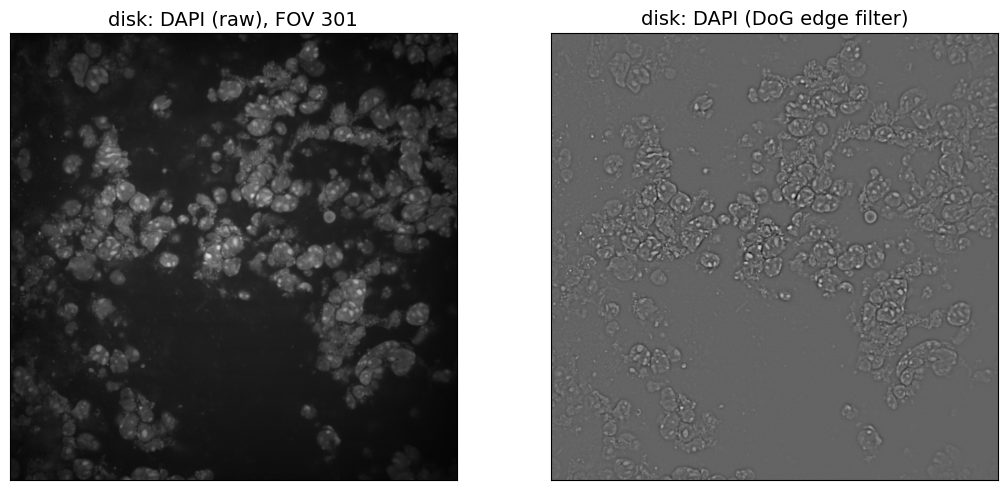

In [6]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(11, 5 * len(DATASETS)), squeeze=False)
for row, (dataset_label, R) in enumerate(RESULTS.items()):
    dataset_geo = R["dataset_geo"]
    sample_fov = int(R["self_shift_df"]["fov_id"].iloc[0])
    sample = R["load_channel_frames"](sample_fov)
    axes[row, 0].imshow(sample["dapi_raw"], cmap="gray")
    axes[row, 0].set_title(f"{dataset_label}: DAPI (raw), FOV {sample_fov}", fontsize=PLOT_TITLE_FONTSIZE)
    axes[row, 1].imshow(sample["dapi_edge"], cmap="gray")
    axes[row, 1].set_title(f"{dataset_label}: DAPI (DoG edge filter)", fontsize=PLOT_TITLE_FONTSIZE)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(RESULTS["disk"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.raw_vs_edge_example.png", dpi=150)
plt.show()

## 6 — Self-shift curves (display)

If this notebook's machinery is doing what it's supposed to, every
channel's curve MUST pass through `correlation=1.0` at `shift_px=0`.

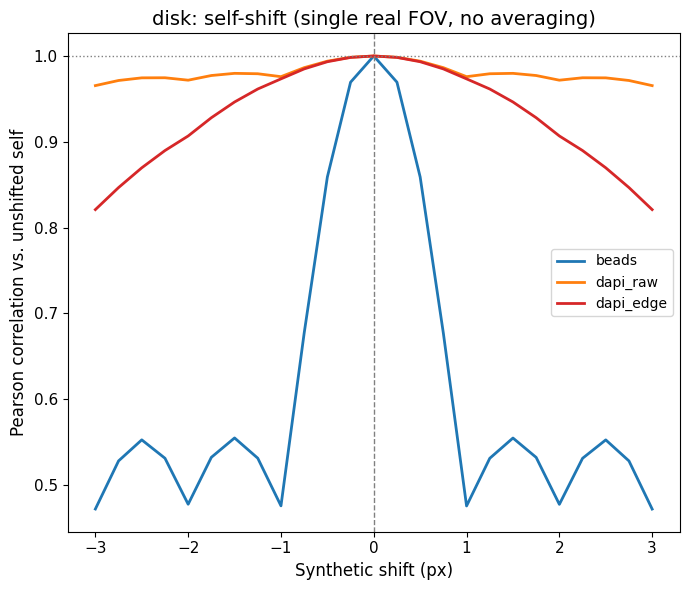

Sanity check -- correlation at shift=0 (must be 1.0 everywhere):
  [disk] beads=1.000000  dapi_raw=1.000000  dapi_edge=1.000000


In [7]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7 * len(DATASETS), 6), squeeze=False)
for col, (dataset_label, R) in enumerate(RESULTS.items()):
    ax = axes[0, col]
    df = R["self_shift_df"]
    for channel in CHANNELS:
        sub = df[df["channel"] == channel].sort_values("shift_px")
        ax.plot(sub["shift_px"], sub["correlation"], label=channel, color=CHANNEL_COLORS[channel], linewidth=2)
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Synthetic shift (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Pearson correlation vs. unshifted self", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: self-shift (single real FOV, no averaging)", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()
fig.savefig(RESULTS["disk"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.self_shift_curves.png", dpi=150)
plt.show()

print("Sanity check -- correlation at shift=0 (must be 1.0 everywhere):")
for dataset_label, R in RESULTS.items():
    df = R["self_shift_df"]
    at0 = df[np.isclose(df["shift_px"], 0.0)].set_index("channel")["correlation"]
    print(f"  [{dataset_label}] " + "  ".join(f"{ch}={at0[ch]:.6f}" for ch in CHANNELS))

## 7 — Cross-tile test: real edges, single + averaged (calculation)

Identical methodology to `test_dapi_inversion.ipynb`: sample real 4-connected
edges, measure each edge's real best-alignment shift via `phase_drift`
first, then sweep `SHIFT_RANGE_PX` centered on that measured shift (not on
the nominal grid position) along the overlap band's short axis.

In [8]:
def compute_edge_shift_curves(dataset_geo, load_frame_for_channel):
    cache_csv = dataset_geo["cache_dir"] / "edge_shift_curves.csv"
    if not FORCE_RECOMPUTE and cache_csv.exists():
        df = pd.read_csv(cache_csv)
        print(f"[{dataset_geo['dataset_label']}] Loaded cached edge shift curves from {cache_csv}")
        return df

    full_positions   = dataset_geo["full_positions"]
    step_size_um     = dataset_geo["step_size_um"]
    overlap_fraction = dataset_geo["overlap_fraction"]

    rng = np.random.default_rng(SEED)
    candidates = list(dataset_geo["cells_fov_ids"])
    rng.shuffle(candidates)

    sampled_edges = []   # (anchor_fov, neighbor_fov, direction)
    for anchor_fov in candidates:
        for direction in ("up", "down", "left", "right"):
            neighbor_fov = find_grid_neighbor(anchor_fov, full_positions, direction, step_size_um, TOLERANCE_FRACTION)
            if neighbor_fov is not None:
                sampled_edges.append((anchor_fov, neighbor_fov, direction))
        if len(sampled_edges) >= N_EDGES_FOR_SHIFT_CURVE:
            break
    sampled_edges = sampled_edges[:N_EDGES_FOR_SHIFT_CURVE]
    print(f"[{dataset_geo['dataset_label']}] Sampled {len(sampled_edges)} real edges: {sampled_edges}")

    reporter = ProgressReporter(total=len(sampled_edges) * len(CHANNELS) * len(SHIFT_RANGE_PX),
                                 label=f"[{dataset_geo['dataset_label']}] Computing edge shift curves")
    rows = []
    for edge_id, (anchor_fov, neighbor_fov, direction) in enumerate(sampled_edges):
        shift_axis = "col" if direction in ("left", "right") else "row"
        for channel in CHANNELS:
            anchor_img   = load_frame_for_channel(channel)(anchor_fov)
            neighbor_img = load_frame_for_channel(channel)(neighbor_fov)
            a_crop, n_crop = crop_overlap(anchor_img, neighbor_img, direction, overlap_fraction)
            a_crop = remove_hot_pixels(a_crop).astype(np.float64)
            n_crop = remove_hot_pixels(n_crop).astype(np.float64)

            base_shift, base_error = phase_drift(a_crop, n_crop, UPSAMPLE_FACTOR)
            base_dy, base_dx = float(base_shift[0]), float(base_shift[1])

            for shift_px in SHIFT_RANGE_PX:
                delta = (0.0, float(shift_px)) if shift_axis == "col" else (float(shift_px), 0.0)
                shift_tuple = (base_dy + delta[0], base_dx + delta[1])
                shifted = ndi_shift(n_crop, shift=shift_tuple, order=1, mode="nearest")
                a_flat, s_flat = a_crop.ravel(), shifted.ravel()
                corr = 0.0 if a_flat.std() == 0.0 or s_flat.std() == 0.0 else float(np.corrcoef(a_flat, s_flat)[0, 1])
                rows.append({"edge_id": edge_id, "anchor_fov": anchor_fov, "neighbor_fov": neighbor_fov,
                             "direction": direction, "channel": channel, "shift_px": float(shift_px),
                             "correlation": corr, "base_dy_px": base_dy, "base_dx_px": base_dx,
                             "base_registration_error": base_error})
                reporter.update(1)
    reporter.done()

    df = pd.DataFrame(rows)
    df.to_csv(cache_csv, index=False)
    print(f"[{dataset_geo['dataset_label']}] Saved {len(df)} rows to {cache_csv}")
    return df


for dataset_label, R in RESULTS.items():
    R["edge_shift_df"] = compute_edge_shift_curves(R["dataset_geo"], R["load_frame_for_channel"])

[disk] Sampled 8 real edges: [(510, 511, 'up'), (510, 507, 'left'), (291, 292, 'up'), (291, 290, 'down'), (291, 279, 'left'), (291, 329, 'right'), (586, 310, 'down'), (586, 587, 'left')]


[disk] Computing edge shift curves: [------------------------] 1/600 (  0.2%)  elapsed 0s  ETA 4m 53s          

[disk] Computing edge shift curves: [------------------------] 14/600 (  2.3%)  elapsed 1s  ETA 43s          

[disk] Computing edge shift curves: [#-----------------------] 26/600 (  4.3%)  elapsed 2s  ETA 36s          

[disk] Computing edge shift curves: [#-----------------------] 49/600 (  8.2%)  elapsed 2s  ETA 24s          

...

[disk] Computing edge shift curves: [######################--] 562/600 ( 93.7%)  elapsed 45s  ETA 3s          

[disk] Computing edge shift curves: [#######################-] 576/600 ( 96.0%)  elapsed 49s  ETA 2s          

[disk] Computing edge shift curves: [########################] 600/600 (100.0%)  elapsed 49s  ETA 0s          

[disk] Computing edge shift curves: [########################] 600/600 (100.0%)  elapsed 49s  ETA 0s          


[disk] Saved 600 rows to /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_dapi_edge_filter/edge_shift_curves.csv


## 8 — Cross-tile curves: single edge vs. averaged (display)

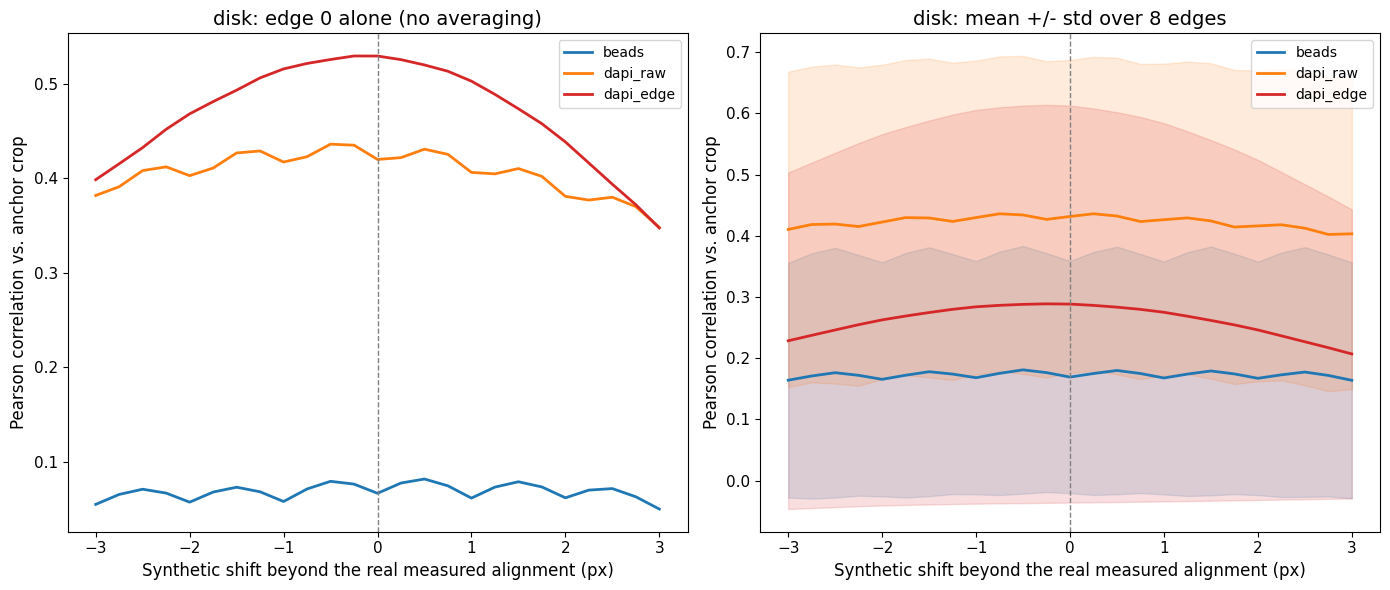

Sharpness proxy (correlation drop from shift=0 to |shift|=1px, mean over edges):
[disk]
  beads     : corr(0)=0.1691  corr(|1px|)=0.1679  drop=0.0012
  dapi_raw  : corr(0)=0.4315  corr(|1px|)=0.4280  drop=0.0035
  dapi_edge : corr(0)=0.2884  corr(|1px|)=0.2795  drop=0.0089


In [9]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(14, 6 * len(DATASETS)), squeeze=False)
for row, (dataset_label, R) in enumerate(RESULTS.items()):
    df = R["edge_shift_df"]

    ax = axes[row, 0]
    single = df[df["edge_id"] == 0]
    for channel in CHANNELS:
        sub = single[single["channel"] == channel].sort_values("shift_px")
        ax.plot(sub["shift_px"], sub["correlation"], label=channel, color=CHANNEL_COLORS[channel], linewidth=2)
    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Synthetic shift beyond the real measured alignment (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Pearson correlation vs. anchor crop", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: edge 0 alone (no averaging)", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)

    ax = axes[row, 1]
    for channel in CHANNELS:
        sub = df[df["channel"] == channel]
        grouped = sub.groupby("shift_px")["correlation"]
        mean, std = grouped.mean(), grouped.std()
        ax.plot(mean.index, mean.values, label=channel, color=CHANNEL_COLORS[channel], linewidth=2)
        ax.fill_between(mean.index, mean.values - std.values, mean.values + std.values,
                         color=CHANNEL_COLORS[channel], alpha=0.15)
    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Synthetic shift beyond the real measured alignment (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Pearson correlation vs. anchor crop", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: mean +/- std over {df['edge_id'].nunique()} edges", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)

fig.tight_layout()
fig.savefig(RESULTS["disk"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.edge_shift_curves.png", dpi=150)
plt.show()

print("Sharpness proxy (correlation drop from shift=0 to |shift|=1px, mean over edges):")
for dataset_label, R in RESULTS.items():
    df = R["edge_shift_df"]
    print(f"[{dataset_label}]")
    for channel in CHANNELS:
        sub = df[df["channel"] == channel]
        at0 = sub[np.isclose(sub["shift_px"], 0.0)].groupby("edge_id")["correlation"].mean()
        at1 = sub[np.isclose(sub["shift_px"].abs(), 1.0)].groupby("edge_id")["correlation"].mean()
        drop = (at0 - at1).mean()
        print(f"  {channel:10s}: corr(0)={at0.mean():.4f}  corr(|1px|)={at1.mean():.4f}  drop={drop:.4f}")

## 9 — Practical test: real neighbor-tile registration, whole-grid sample (calculation)

Same anchor-selection algorithm and batched-replay approach
`test_dapi_inversion.ipynb` used for `disk` (`ANCHOR_BATCH_SIZE=5`,
clearing `raw_cache` between batches) -- that batching was required to
avoid repeated OOM kills on this exact dataset/section; see that
notebook's own `prompt_history/` entries for the full debugging path.

In [10]:
def compute_correspondences(dataset_geo, load_frame_for_channel, raw_cache):
    cache_dir        = dataset_geo["cache_dir"]
    full_positions   = dataset_geo["full_positions"]
    overlap_fraction = dataset_geo["overlap_fraction"]
    pixel_size_um    = dataset_geo["pixel_size_um"]
    step_size_um     = dataset_geo["step_size_um"]
    cells_fov_ids    = dataset_geo["cells_fov_ids"]

    rng = np.random.default_rng(SEED)
    candidates = list(cells_fov_ids)
    rng.shuffle(candidates)
    anchors = candidates[:N_ANCHORS]

    dfs = {}
    for channel in CHANNELS:
        corr_csv = cache_dir / f"correspondences_{channel}.csv"
        if not FORCE_RECOMPUTE and corr_csv.exists():
            df = pd.read_csv(corr_csv)
            print(f"[{dataset_geo['dataset_label']}][{channel}] Loaded {len(df)} cached correspondences from {corr_csv}")
        else:
            load_frame = load_frame_for_channel(channel)
            reporter = ProgressReporter(total=len(anchors) * 4,
                                         label=f"[{dataset_geo['dataset_label']}][{channel}] Registering edges")
            rows = []
            for batch_start in range(0, len(anchors), ANCHOR_BATCH_SIZE):
                for anchor_fov in anchors[batch_start:batch_start + ANCHOR_BATCH_SIZE]:
                    anchor_img = load_frame(anchor_fov)
                    for direction in ("up", "down", "left", "right"):
                        neighbor_fov = find_grid_neighbor(anchor_fov, full_positions, direction,
                                                           step_size_um, TOLERANCE_FRACTION)
                        reporter.update(1)
                        if neighbor_fov is None:
                            continue
                        neighbor_img = load_frame(neighbor_fov)
                        nominal_xy = full_positions[neighbor_fov]
                        measured_xy, error = register_neighbor_pair(
                            anchor_img, neighbor_img, full_positions[anchor_fov], nominal_xy,
                            direction, overlap_fraction, pixel_size_um, UPSAMPLE_FACTOR,
                        )
                        achieved_shift_um = (measured_xy[0] - nominal_xy[0], measured_xy[1] - nominal_xy[1])
                        achieved_corr = overlap_correlation(anchor_img, neighbor_img, direction, overlap_fraction,
                                                             extra_shift_um=achieved_shift_um, pixel_size_um=pixel_size_um)
                        nominal_corr  = overlap_correlation(anchor_img, neighbor_img, direction, overlap_fraction,
                                                             extra_shift_um=(0.0, 0.0), pixel_size_um=pixel_size_um)
                        rows.append({
                            "anchor_fov": anchor_fov, "neighbor_fov": neighbor_fov, "direction": direction,
                            "nominal_x": nominal_xy[0], "nominal_y": nominal_xy[1],
                            "measured_x": measured_xy[0], "measured_y": measured_xy[1],
                            "shift_um": float(np.hypot(*achieved_shift_um)),
                            "error": error, "achieved_correlation": achieved_corr, "nominal_correlation": nominal_corr,
                        })
                raw_cache.clear()
                gc.collect()
            reporter.done()

            df = pd.DataFrame(rows)
            df.to_csv(corr_csv, index=False)
            print(f"[{dataset_geo['dataset_label']}][{channel}] Saved {len(df)} correspondences to {corr_csv}")
        df["channel"] = channel
        dfs[channel] = df
    return dfs


for dataset_label, R in RESULTS.items():
    R["correspondence_dfs"] = compute_correspondences(R["dataset_geo"], R["load_frame_for_channel"], R["raw_cache"])
    total = sum(len(d) for d in R["correspondence_dfs"].values())
    print(f"[{dataset_label}] Total correspondence rows: {total}")

[disk][beads] Registering edges: [------------------------] 1/80 (  1.2%)  elapsed 0s  ETA 0s          

[disk][beads] Registering edges: [------------------------] 2/80 (  2.5%)  elapsed 1s  ETA 25s          

[disk][beads] Registering edges: [#-----------------------] 4/80 (  5.0%)  elapsed 1s  ETA 24s          

[disk][beads] Registering edges: [#-----------------------] 6/80 (  7.5%)  elapsed 2s  ETA 23s          

[disk][beads] Registering edges: [##----------------------] 7/80 (  8.8%)  elapsed 2s  ETA 26s          

...

[disk][dapi_edge] Registering edges: [#######################-] 78/80 ( 97.5%)  elapsed 3m 17s  ETA 5s          

[disk][dapi_edge] Registering edges: [#######################-] 79/80 ( 98.8%)  elapsed 3m 19s  ETA 3s          

[disk][dapi_edge] Registering edges: [########################] 80/80 (100.0%)  elapsed 3m 21s  ETA 0s          

[disk][dapi_edge] Registering edges: [########################] 80/80 (100.0%)  elapsed 3m 24s  ETA 0s          


[disk][dapi_edge] Saved 76 correspondences to /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_dapi_edge_filter/correspondences_dapi_edge.csv
[disk] Total correspondence rows: 228


## 10 — Achieved correlation + measured-shift comparison (display)

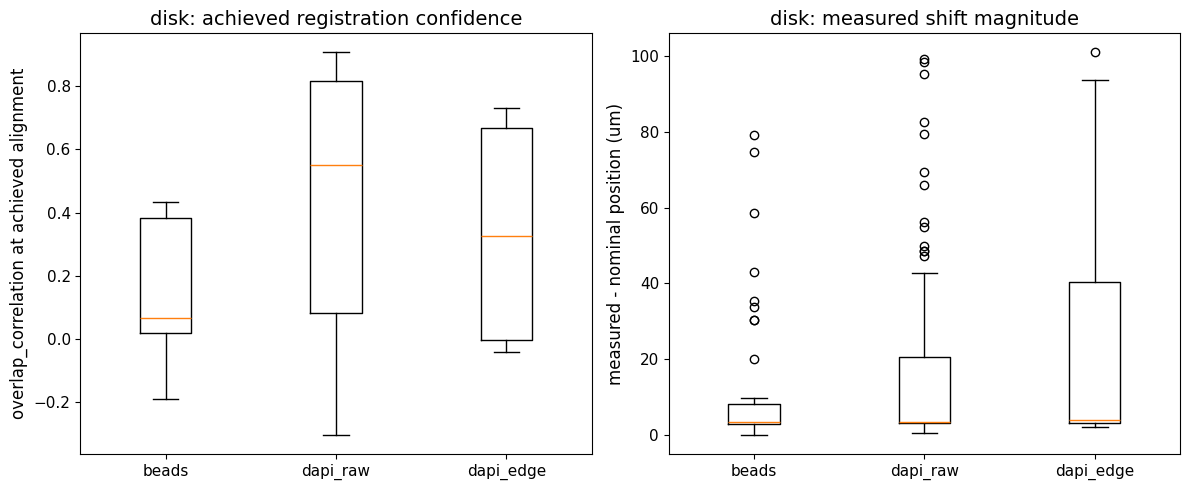

Summary (mean +/- std):
[disk]
  beads     : achieved_corr=0.1823+/-0.1844  nominal_corr=0.1766+/-0.1888  shift_um=9.236+/-15.059  error(saturated,ignored)=1.0000  (n=76)
  dapi_raw  : achieved_corr=0.4884+/-0.3665  nominal_corr=0.4160+/-0.1274  shift_um=17.364+/-26.434  error(saturated,ignored)=1.0000  (n=76)
  dapi_edge : achieved_corr=0.3307+/-0.3360  nominal_corr=-0.0044+/-0.0201  shift_um=25.094+/-30.222  error(saturated,ignored)=1.0000  (n=76)


In [11]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(12, 5 * len(DATASETS)), squeeze=False)
for row, (dataset_label, R) in enumerate(RESULTS.items()):
    dfs = R["correspondence_dfs"]

    ax = axes[row, 0]
    data_corr = [dfs[c]["achieved_correlation"].values for c in CHANNELS]
    ax.boxplot(data_corr, tick_labels=CHANNELS)
    ax.set_ylabel("overlap_correlation at achieved alignment", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: achieved registration confidence", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

    ax = axes[row, 1]
    data_shift = [dfs[c]["shift_um"].values for c in CHANNELS]
    ax.boxplot(data_shift, tick_labels=CHANNELS)
    ax.set_ylabel("measured - nominal position (um)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: measured shift magnitude", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.tight_layout()
fig.savefig(RESULTS["disk"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.achieved_correlation_and_shift.png", dpi=150)
plt.show()

print("Summary (mean +/- std):")
for dataset_label, R in RESULTS.items():
    print(f"[{dataset_label}]")
    for channel in CHANNELS:
        d = R["correspondence_dfs"][channel]
        print(f"  {channel:10s}: achieved_corr={d['achieved_correlation'].mean():.4f}+/-{d['achieved_correlation'].std():.4f}  "
              f"nominal_corr={d['nominal_correlation'].mean():.4f}+/-{d['nominal_correlation'].std():.4f}  "
              f"shift_um={d['shift_um'].mean():.3f}+/-{d['shift_um'].std():.3f}  "
              f"error(saturated,ignored)={d['error'].mean():.4f}  (n={len(d)})")

## 11 — Discussion

**Real result: DoG edge-filtering measurably sharpens DAPI's correlation
RESPONSE to a small shift, confirming the Cramer-Rao-based prediction --
but does not improve DAPI's ACHIEVED registration confidence on real
`disk` tiles, and falls well short of closing the gap to beads.**

- **Section 6 sanity check passes**: `correlation=1.000000` at `shift_px=0`
  for all three channels -- machinery correct.
- **Section 6 self-shift curve (cleanest test, one real image vs. a
  synthetic shift of itself, no cross-image noise)**: `dapi_edge` decays
  MUCH faster than `dapi_raw` -- `corr(3px)`: beads=0.472, dapi_edge=0.821,
  dapi_raw=0.965. This is a real, substantial sharpening (DoG's explicit
  boost of high-spatial-frequency content raises `integral((dI/dx)^2)`,
  exactly as the Cramer-Rao framing predicts) -- but `dapi_edge` still
  falls far short of beads, which already drop to ~0.48 by 1px. Soft,
  multi-pixel nuclear edges evidently still can't match a near-point
  source's frequency content, even after enhancement.
- **Section 8 cross-tile curves (real anchor/neighbour pairs)**: same
  direction of effect. The single real edge (left panel) shows `dapi_edge`
  reaching a distinctly higher peak (~0.53) than `dapi_raw` (~0.42) right
  at the true alignment. Averaged over 8 edges, `dapi_edge`'s shift
  sensitivity is clearly higher too -- the 0px-to-1px correlation drop is
  0.0089 for `dapi_edge` vs. 0.0035 for `dapi_raw` (beads: 0.0012, weak on
  `disk` as expected) -- but `dapi_edge`'s mean ABSOLUTE correlation
  (~0.29) is lower than `dapi_raw`'s (~0.41) across the same 8 edges: DoG
  removes low-frequency content that, on real independently-acquired image
  pairs, was apparently still carrying real, shared (not just
  shift-sensitive) structure -- the curve got sharper but also smaller.
- **Section 10 practical whole-grid sample -- the one that matters for a
  real decision**: `dapi_edge`'s own end-to-end registration
  (`register_neighbor_pair` run on the edge-filtered channel itself, not
  swept around another channel's alignment) achieves a LOWER median
  correlation confidence (0.33) than `dapi_raw`'s (0.55), with a larger,
  noisier measured-shift distribution (mean 25.1um vs. 17.4um, more large
  outliers) -- `dapi_edge`'s `nominal_correlation` (before any registration
  correction) is also near zero (-0.004 +/- 0.02), confirming DoG strips
  out the low-frequency content that let `dapi_raw` tiles correlate at all
  before alignment. On this specific, real, noisy dataset, `phase_drift`
  applied directly to the edge-filtered channel is a less robust shift
  estimator in practice than on raw DAPI, even though its local response
  to a KNOWN small shift is sharper in isolation.
- **Sanity check on the filter itself**: Section 4's sample image shows the
  DoG output (`low_sigma=1px`, `high_sigma=8px`) cleanly resolves individual
  cell/nucleus boundaries on a real `disk` FOV -- the filter is doing what
  it visually should; the mismatch above is about registration robustness
  on real noisy data, not a broken filter.

**Bottom line**: the edge-detection idea is mechanistically correct and
measurably confirmed -- DoG-filtered DAPI has a sharper theoretical
correlation response than raw DAPI, exactly as the Cramer-Rao/gradient-
energy framing predicts. But "sharper local response" and "better real
registration outcome" are different questions on real, noisy data: this
specific test found DoG-filtered DAPI performs WORSE in the practical
whole-grid registration test on `disk`, most likely because throwing away
low-frequency content also throws away real shared structure between two
independently noisy real exposures, and destabilizes `phase_drift`'s own
peak-finding on this dataset. Neither raw nor edge-filtered DAPI comes
close to beads' sharpness in the cleanest (self-shift) test. Don't adopt
DoG-filtered DAPI as a production registration channel based on this
result -- if pursued further, worth testing on `epi` (stronger signal,
less noisy) and/or tuning `high_sigma` against a properly measured nucleus
size, since this run's sigma choice was a visually-checked default, not an
optimized one (see Section 2's own note on why the automatic estimate
failed on this dataset).